In [ ]:
!mkdir -p /content/vision_interpretability/src
!mkdir -p /content/vision_interpretability/results
!mkdir -p /content/vision_interpretability/images

!ls -R /content/vision_interpretability

/content/vision_interpretability:
images	results  src

/content/vision_interpretability/images:

/content/vision_interpretability/results:

/content/vision_interpretability/src:


In [ ]:
!pip install torch torchvision matplotlib numpy pillow opencv-python requests

In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

device = "cuda" if torch.cuda.is_available() else "cpu"

model = torchvision.models.resnet18(pretrained=True)
model.eval()
model.to(device)

print("Model loaded.")
print("Using device:", device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 137MB/s]


Model loaded.
Using device: cuda


In [ ]:
import requests
from io import BytesIO
from PIL import Image

url = "https://upload.wikimedia.org/wikipedia/commons/6/6e/Golde33443.jpg"

response = requests.get(url)
img = Image.open(BytesIO(response.content)).convert("RGB")

plt.imshow(img)
plt.axis("off")
plt.show()

UnidentifiedImageError: cannot identify image file <_io.BytesIO object at 0x7b8905d02a70>

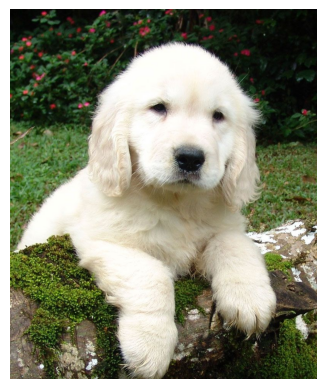

In [ ]:
import requests
from io import BytesIO
from PIL import Image
import matplotlib.pyplot as plt

url = "https://upload.wikimedia.org/wikipedia/commons/6/6e/Golde33443.jpg"

headers = {
    "User-Agent": "Mozilla/5.0"
}

response = requests.get(url, headers=headers)

img = Image.open(BytesIO(response.content)).convert("RGB")

plt.imshow(img)
plt.axis("off")
plt.show()

In [ ]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

input_tensor = transform(img).unsqueeze(0).to(device)
print(input_tensor.shape)

torch.Size([1, 3, 224, 224])


In [ ]:
with torch.no_grad():
    output = model(input_tensor)

pred_class = output.argmax().item()

print("Predicted class index:", pred_class)

Predicted class index: 222


In [ ]:
gradients = []
activations = []

def forward_hook(module, input, output):
    activations.append(output)

def backward_hook(module, grad_input, grad_output):
    gradients.append(grad_output[0])

target_layer = model.layer4[1].conv2

forward_handle = target_layer.register_forward_hook(forward_hook)
backward_handle = target_layer.register_full_backward_hook(backward_hook)

In [ ]:
gradients.clear()
activations.clear()

output = model(input_tensor)
pred_class = output.argmax()

model.zero_grad()
output[0, pred_class].backward()

grads = gradients[0]        # gradients wrt feature maps
acts = activations[0]       # feature maps themselves

weights = grads.mean(dim=[2, 3], keepdim=True)
cam = (weights * acts).sum(dim=1)
cam = torch.relu(cam)

cam = cam.squeeze().detach().cpu().numpy()
cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

In [ ]:
forward_handle.remove()
backward_handle.remove()

In [ ]:
import json
import requests

labels_url = "https://s3.amazonaws.com/deep-learning-models/image-models/imagenet_class_index.json"
labels = requests.get(labels_url).json()

pred_label = labels[str(pred_class.item())][1] if hasattr(pred_class, "item") else labels[str(pred_class)][1]
print("Predicted label:", pred_label)

Predicted label: kuvasz


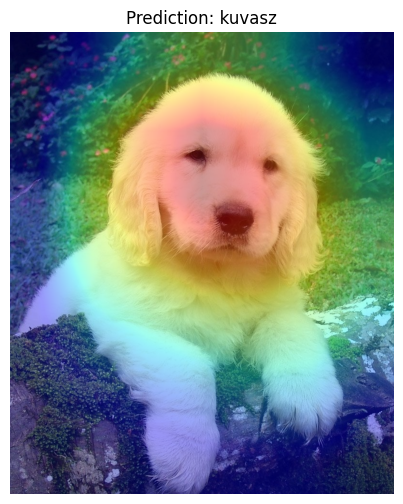

In [ ]:
plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.imshow(heatmap, cmap="jet", alpha=0.4)
plt.axis("off")
plt.title(f"Prediction: {pred_label}")
plt.savefig("/content/vision_interpretability/results/dog_gradcam.png", bbox_inches="tight")
plt.show()

In [ ]:
img.save("/content/vision_interpretability/images/dog_input.jpg")

In [ ]:
print("Final result")
print("Predicted class index:", pred_class.item() if hasattr(pred_class, "item") else pred_class)
print("Predicted label:", pred_label)
print("Saved Grad-CAM to: /content/vision_interpretability/results/dog_gradcam.png")

Final result
Predicted class index: 222
Predicted label: kuvasz
Saved Grad-CAM to: /content/vision_interpretability/results/dog_gradcam.png


In [ ]:
def run_gradcam_on_image(url, save_path):
    import requests
    from io import BytesIO
    from PIL import Image
    import cv2
    import matplotlib.pyplot as plt

    headers = {"User-Agent": "Mozilla/5.0"}
    response = requests.get(url, headers=headers)
    img = Image.open(BytesIO(response.content)).convert("RGB")

    input_tensor = transform(img).unsqueeze(0).to(device)

    gradients = []
    activations = []

    def forward_hook(module, input, output):
        activations.append(output)

    def backward_hook(module, grad_input, grad_output):
        gradients.append(grad_output[0])

    target_layer = model.layer4[1].conv2
    forward_handle = target_layer.register_forward_hook(forward_hook)
    backward_handle = target_layer.register_full_backward_hook(backward_hook)

    output = model(input_tensor)
    pred_class = output.argmax()

    model.zero_grad()
    output[0, pred_class].backward()

    grads = gradients[0]
    acts = activations[0]

    weights = grads.mean(dim=[2, 3], keepdim=True)
    cam = (weights * acts).sum(dim=1)
    cam = torch.relu(cam)

    cam = cam.squeeze().detach().cpu().numpy()
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

    heatmap = cv2.resize(cam, (img.size[0], img.size[1]))

    pred_label = labels[str(pred_class.item())][1]

    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.imshow(heatmap, cmap="jet", alpha=0.4)
    plt.axis("off")
    plt.title(f"Prediction: {pred_label}")
    plt.savefig(save_path, bbox_inches="tight")
    plt.show()

    forward_handle.remove()
    backward_handle.remove()

    return pred_label

In [ ]:
from google.colab import files
uploaded = files.upload()

In [ ]:
import requests

labels_url = "https://s3.amazonaws.com/deep-learning-models/image-models/imagenet_class_index.json"
labels = requests.get(labels_url).json()

print("Predicted label:", labels[str(pred_class.item())][1])

Predicted label: kuvasz


In [ ]:
img.save("/content/vision_interpretability/images/dog_input.jpg")

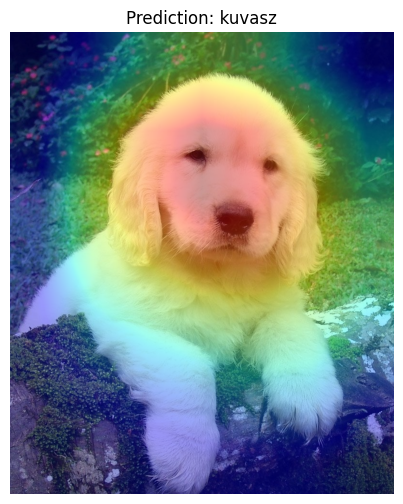

In [ ]:
pred_label = labels[str(pred_class.item())][1]

plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.imshow(heatmap, cmap="jet", alpha=0.4)
plt.axis("off")
plt.title(f"Prediction: {pred_label}")
plt.savefig("/content/vision_interpretability/results/dog_gradcam.png", bbox_inches="tight")
plt.show()

In [ ]:
print("Done.")
print("Prediction:", pred_label)
print("Original image saved to /content/vision_interpretability/images/dog_input.jpg")
print("Grad-CAM result saved to /content/vision_interpretability/results/dog_gradcam.png")

Done.
Prediction: kuvasz
Original image saved to /content/vision_interpretability/images/dog_input.jpg
Grad-CAM result saved to /content/vision_interpretability/results/dog_gradcam.png


In [ ]:
import requests
from io import BytesIO
from PIL import Image
import matplotlib.pyplot as plt
import cv2
import torch

def run_gradcam_from_url(url, output_name):
    headers = {"User-Agent": "Mozilla/5.0"}
    response = requests.get(url, headers=headers)
    img = Image.open(BytesIO(response.content)).convert("RGB")

    input_tensor = transform(img).unsqueeze(0).to(device)

    gradients = []
    activations = []

    def forward_hook(module, input, output):
        activations.append(output)

    def backward_hook(module, grad_input, grad_output):
        gradients.append(grad_output[0])

    target_layer = model.layer4[1].conv2
    forward_handle = target_layer.register_forward_hook(forward_hook)
    backward_handle = target_layer.register_full_backward_hook(backward_hook)

    output = model(input_tensor)
    pred_class = output.argmax()

    model.zero_grad()
    output[0, pred_class].backward()

    grads = gradients[0]
    acts = activations[0]

    weights = grads.mean(dim=[2, 3], keepdim=True)
    cam = (weights * acts).sum(dim=1)
    cam = torch.relu(cam)

    cam = cam.squeeze().detach().cpu().numpy()
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

    heatmap = cv2.resize(cam, (img.size[0], img.size[1]))
    pred_label = labels[str(pred_class.item())][1]

    input_path = f"/content/vision_interpretability/images/{output_name}_input.jpg"
    output_path = f"/content/vision_interpretability/results/{output_name}_gradcam.png"

    img.save(input_path)

    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.imshow(heatmap, cmap="jet",

SyntaxError: incomplete input (1223619306.py, line 54)

In [ ]:
import requests
from io import BytesIO
from PIL import Image
import matplotlib.pyplot as plt
import cv2
import torch

def run_gradcam_from_url(url, output_name):

    headers = {"User-Agent": "Mozilla/5.0"}
    response = requests.get(url, headers=headers)
    img = Image.open(BytesIO(response.content)).convert("RGB")

    input_tensor = transform(img).unsqueeze(0).to(device)

    gradients = []
    activations = []

    def forward_hook(module, input, output):
        activations.append(output)

    def backward_hook(module, grad_input, grad_output):
        gradients.append(grad_output[0])

    target_layer = model.layer4[1].conv2

    forward_handle = target_layer.register_forward_hook(forward_hook)
    backward_handle = target_layer.register_full_backward_hook(backward_hook)

    output = model(input_tensor)
    pred_class = output.argmax()

    model.zero_grad()
    output[0, pred_class].backward()

    grads = gradients[0]
    acts = activations[0]

    weights = grads.mean(dim=[2,3], keepdim=True)
    cam = (weights * acts).sum(dim=1)
    cam = torch.relu(cam)

    cam = cam.squeeze().detach().cpu().numpy()
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

    heatmap = cv2.resize(cam, (img.size[0], img.size[1]))

    pred_label = labels[str(pred_class.item())][1]

    input_path = f"/content/vision_interpretability/images/{output_name}_input.jpg"
    output_path = f"/content/vision_interpretability/results/{output_name}_gradcam.png"

    img.save(input_path)

    plt.figure(figsize=(6,6))
    plt.imshow(img)
    plt.imshow(heatmap, cmap="jet", alpha=0.4)
    plt.axis("off")
    plt.title(f"Prediction: {pred_label}")
    plt.savefig(output_path, bbox_inches="tight")
    plt.show()

    forward_handle.remove()
    backward_handle.remove()

    print("Prediction:", pred_label)
    print("Saved input:", input_path)
    print("Saved Grad-CAM:", output_path)

In [ ]:
import requests
from io import BytesIO
from PIL import Image
import matplotlib.pyplot as plt
import cv2
import torch

def run_gradcam_from_url(url, output_name):
    headers = {"User-Agent": "Mozilla/5.0"}
    response = requests.get(url, headers=headers)
    img = Image.open(BytesIO(response.content)).convert("RGB")

    input_tensor = transform(img).unsqueeze(0).to(device)

    gradients = []
    activations = []

    def forward_hook(module, input, output):
        activations.append(output)

    def backward_hook(module, grad_input, grad_output):
        gradients.append(grad_output[0])

    target_layer = model.layer4[1].conv2
    forward_handle = target_layer.register_forward_hook(forward_hook)
    backward_handle = target_layer.register_full_backward_hook(backward_hook)

    output = model(input_tensor)
    pred_class = output.argmax()

    model.zero_grad()
    output[0, pred_class].backward()

    grads = gradients[0]
    acts = activations[0]

    weights = grads.mean(dim=[2, 3], keepdim=True)
    cam = (weights * acts).sum(dim=1)
    cam = torch.relu(cam)

    cam = cam.squeeze().detach().cpu().numpy()
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

    heatmap = cv2.resize(cam, (img.size[0], img.size[1]))
    pred_label = labels[str(pred_class.item())][1]

    input_path = f"/content/vision_interpretability/images/{output_name}_input.jpg"
    output_path = f"/content/vision_interpretability/results/{output_name}_gradcam.png"

    img.save(input_path)

    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.imshow(heatmap, cmap="jet", alpha=0.4)
    plt.axis("off")
    plt.title(f"Prediction: {pred_label}")
    plt.savefig(output_path, bbox_inches="tight")
    plt.show()

    forward_handle.remove()
    backward_handle.remove()

    print("Prediction:", pred_label)
    print("Saved input:", input_path)
    print("Saved Grad-CAM:", output_path)

    return pred_label

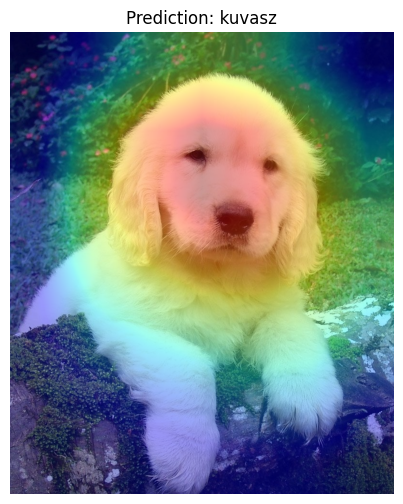

Prediction: kuvasz
Saved input: /content/vision_interpretability/images/dog_input.jpg
Saved Grad-CAM: /content/vision_interpretability/results/dog_gradcam.png


'kuvasz'

In [ ]:
run_gradcam_from_url(
"https://upload.wikimedia.org/wikipedia/commons/6/6e/Golde33443.jpg",
"dog"
)

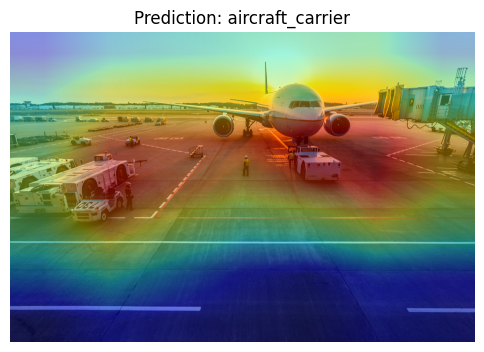

Prediction: aircraft_carrier
Saved input: /content/vision_interpretability/images/airplane_input.jpg
Saved Grad-CAM: /content/vision_interpretability/results/airplane_gradcam.png


'aircraft_carrier'

In [ ]:
run_gradcam_from_url(
"https://images.unsplash.com/photo-1542296332-2e4473faf563",
"airplane"
)

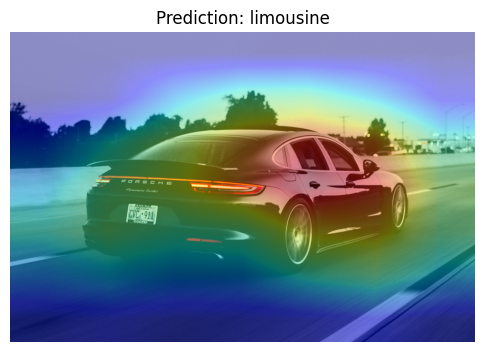

Prediction: limousine
Saved input: /content/vision_interpretability/images/car_input.jpg
Saved Grad-CAM: /content/vision_interpretability/results/car_gradcam.png


'limousine'

In [ ]:
run_gradcam_from_url(
"https://images.unsplash.com/photo-1503376780353-7e6692767b70",
"car"
)

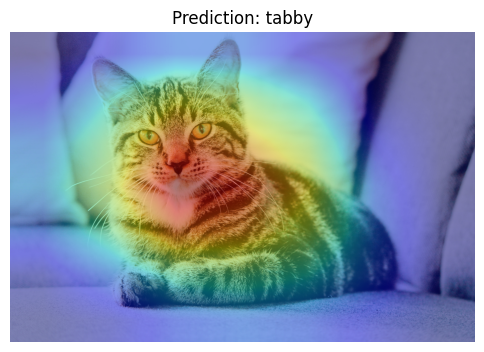

Prediction: tabby
Saved input: /content/vision_interpretability/images/cat_input.jpg
Saved Grad-CAM: /content/vision_interpretability/results/cat_gradcam.png


'tabby'

In [ ]:
run_gradcam_from_url(
"https://images.unsplash.com/photo-1518791841217-8f162f1e1131",
"cat"
)

In [ ]:
!zip -r vision_interpretability.zip /content/vision_interpretability

  adding: content/vision_interpretability/ (stored 0%)
  adding: content/vision_interpretability/results/ (stored 0%)
  adding: content/vision_interpretability/results/cat_gradcam.png (deflated 0%)
  adding: content/vision_interpretability/results/car_gradcam.png (deflated 0%)
  adding: content/vision_interpretability/results/dog_gradcam.png (deflated 0%)
  adding: content/vision_interpretability/results/airplane_gradcam.png (deflated 0%)
  adding: content/vision_interpretability/src/ (stored 0%)
  adding: content/vision_interpretability/images/ (stored 0%)
  adding: content/vision_interpretability/images/dog_input.jpg (deflated 0%)
  adding: content/vision_interpretability/images/car_input.jpg (deflated 2%)
  adding: content/vision_interpretability/images/airplane_input.jpg (deflated 2%)
  adding: content/vision_interpretability/images/cat_input.jpg (deflated 1%)


In [ ]:
from google.colab import files
files.download("vision_interpretability.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [49]:
!mkdir -p /content/vision_interpretability/src
!mkdir -p /content/vision_interpretability/results
!mkdir -p /content/vision_interpretability/images

In [50]:
!pip install torch torchvision matplotlib numpy pillow opencv-python requests gradio

In [51]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import cv2
import requests
import gradio as gr
from io import BytesIO
from PIL import Image

device = "cuda" if torch.cuda.is_available() else "cpu"

model = torchvision.models.resnet18(weights=torchvision.models.ResNet18_Weights.DEFAULT)
model.eval()
model.to(device)

print("Model loaded.")
print("Using device:", device)

Model loaded.
Using device: cuda


In [52]:
labels_url = "https://s3.amazonaws.com/deep-learning-models/image-models/imagenet_class_index.json"
labels = requests.get(labels_url).json()

print("Labels loaded.")

Labels loaded.


In [53]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [54]:
def run_gradcam_from_pil(img, output_name="uploaded_image"):
    img = img.convert("RGB")

    input_tensor = transform(img).unsqueeze(0).to(device)

    gradients = []
    activations = []

    def forward_hook(module, input, output):
        activations.append(output)

    def backward_hook(module, grad_input, grad_output):
        gradients.append(grad_output[0])

    target_layer = model.layer4[1].conv2
    forward_handle = target_layer.register_forward_hook(forward_hook)
    backward_handle = target_layer.register_full_backward_hook(backward_hook)

    output = model(input_tensor)
    pred_class = output.argmax()

    model.zero_grad()
    output[0, pred_class].backward()

    grads = gradients[0]
    acts = activations[0]

    weights = grads.mean(dim=[2, 3], keepdim=True)
    cam = (weights * acts).sum(dim=1)
    cam = torch.relu(cam)

    cam = cam.squeeze().detach().cpu().numpy()
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

    heatmap = cv2.resize(cam, (img.size[0], img.size[1]))
    pred_label = labels[str(pred_class.item())][1]

    input_path = f"/content/vision_interpretability/images/{output_name}_input.jpg"
    output_path = f"/content/vision_interpretability/results/{output_name}_gradcam.png"

    img.save(input_path)

    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.imshow(heatmap, cmap="jet", alpha=0.4)
    plt.axis("off")
    plt.title(f"Prediction: {pred_label}")
    plt.savefig(output_path, bbox_inches="tight")
    plt.close()

    forward_handle.remove()
    backward_handle.remove()

    return pred_label, input_path, output_path

In [55]:
def get_top3_predictions(img):
    img = img.convert("RGB")
    input_tensor = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(input_tensor)
        probs = torch.nn.functional.softmax(output[0], dim=0)
        top_probs, top_idxs = torch.topk(probs, 3)

    results = []
    for prob, idx in zip(top_probs, top_idxs):
        label = labels[str(idx.item())][1]
        results.append(f"{label}: {prob.item():.4f}")

    return "\n".join(results)

In [56]:
def gradcam_app(image):
    if image is None:
        return None, "No image uploaded.", ""

    pred_label, input_path, output_path = run_gradcam_from_pil(image, "user_upload")
    top3 = get_top3_predictions(image)

    gradcam_image = Image.open(output_path)

    return gradcam_image, pred_label, top3

In [57]:
demo = gr.Interface(
    fn=gradcam_app,
    inputs=gr.Image(type="pil", label="Upload an image"),
    outputs=[
        gr.Image(type="pil", label="Grad-CAM Overlay"),
        gr.Textbox(label="Predicted Class"),
        gr.Textbox(label="Top-3 Predictions")
    ],
    title="Vision Model Interpretability with Grad-CAM",
    description="Upload an image to see a ResNet-18 prediction, top-3 classes, and a Grad-CAM heatmap."
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://457057aaa0cec5283f.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
!zip -r vision_interpretability_backup.zip /content/vision_interpretability

  adding: content/vision_interpretability/ (stored 0%)
  adding: content/vision_interpretability/results/ (stored 0%)
  adding: content/vision_interpretability/results/cat_gradcam.png (deflated 0%)
  adding: content/vision_interpretability/results/car_gradcam.png (deflated 0%)
  adding: content/vision_interpretability/results/dog_gradcam.png (deflated 0%)
  adding: content/vision_interpretability/results/airplane_gradcam.png (deflated 0%)
  adding: content/vision_interpretability/src/ (stored 0%)
  adding: content/vision_interpretability/images/ (stored 0%)
  adding: content/vision_interpretability/images/dog_input.jpg (deflated 0%)
  adding: content/vision_interpretability/images/car_input.jpg (deflated 2%)
  adding: content/vision_interpretability/images/airplane_input.jpg (deflated 2%)
  adding: content/vision_interpretability/images/cat_input.jpg (deflated 1%)


In [ ]:
from google.colab import files
files.download("vision_interpretability_backup.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>